In [30]:
# Install Dependencies
!pip install -U kagglehub
!pip install midaa anndata scanpy matplotlib numpy seaborn scipy umap-learn torchvision torch wandb weave louvain
!pip install python-igraph leidenalg
!pip install --upgrade midaa


  Using cached louvain-0.8.2.tar.gz (4.2 MB)
  Preparing metadata (setup.py) ... done
  Using cached igraph-0.11.9-cp39-abi3-macosx_11_0_arm64.whl.metadata (4.4 kB)
Using cached igraph-0.11.9-cp39-abi3-macosx_11_0_arm64.whl (1.8 MB)
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> [47 lines of output]
      /opt/anaconda3/lib/python3.12/site-packages/setuptools/__init__.py:92: _DeprecatedInstaller: setuptools.installer and fetch_build_eggs are deprecated.
      !!
      
              ********************************************************************************
              Requirements should be satisfied by a PEP 517 installer.
              If you are using pip, you can try `pip install --use-pep517`.
      
              This deprecation is overdue, please update your project and remove deprecated
              calls to avoid build errors in the future.
              ***************************************

In [31]:
conda install -c conda-forge python-louvain

Channels:
 - conda-forge
 - defaults
Platform: osx-arm64
Solving environment: done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [37]:
# ============================================
# SECTION 1 — IMPORTS + WANDB + WEAVE + DATA
# ============================================

import os, struct, warnings
warnings.filterwarnings("ignore")

# --- General scientific ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Torch ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# --- Vision ---
import torchvision
import torchvision.transforms as T

# --- Anndata & Scanpy ---
import anndata as ad
import scanpy as sc

# --- Clustering / Embeddings ---
import umap
import igraph as ig
import leidenalg as la

# --- MIDAA (your local version) ---
import midaa as maa

# --- WandB & Weave ---
import wandb, weave

# WandB login (din key)
os.environ["WANDB_API_KEY"] = "4898c728bd08c56f03aff5f722c3e813ab39c685"
wandb.login()

wandb.init(project="midaa-mnist-master", name="MASTER_NOTEBOOK", reinit=True)

# Weave init (kræver project_name)
weave.init(project_name="midaa-mnist-master")

print("✓ WandB + Weave initialized.")
print("✓ Imports OK.")

# ============================================
# LOAD MNIST (subset 5000)
# ============================================

transform = T.Compose([T.ToTensor()])

mnist = torchvision.datasets.MNIST(
    root="./mnist_data",
    train=True,
    download=True,
    transform=transform
)

# convert to numpy
X = mnist.data.numpy().astype(np.float32) / 255.0
y = mnist.targets.numpy().astype(int)

# --- SUBSET 5000 ---
subset = 1000
X = X[:subset]
y = y[:subset]

# flatten for MIDAA
X_flat = X.reshape(subset, -1)   # (5000, 784)

# --- Create AnnData ---
adata = ad.AnnData(X_flat)
adata.obs["label"] = y.astype(str)

print("✓ MNIST loaded:", X.shape)
print("✓ AnnData:", adata)


wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


wandb: Initializing weave.


Output()

weave: Logged in as Weights & Biases user: s226625.
weave: View Weave data at https://wandb.ai/s226625-danmarks-tekniske-universitet-dtu/midaa-mnist-master/weave


✓ WandB + Weave initialized.
✓ Imports OK.
✓ MNIST loaded: (1000, 28, 28)
✓ AnnData: AnnData object with n_obs × n_vars = 1000 × 784
    obs: 'label'


In [38]:
print("OBS columns:", adata.obs.columns.tolist())


OBS columns: ['label']


Running MIDAA unsupervised...


wandb: Initializing weave.


Output()

weave: Logged in as Weights & Biases user: s226625.
weave: View Weave data at https://wandb.ai/s226625-danmarks-tekniske-universitet-dtu/midaa-scrna/weave
ELBO: 4141879.00000  : 100%|████████████████| 1000/1000 [00:39<00:00, 25.12it/s]


Z shape: (1000, 9)
A shape: (10, 9)


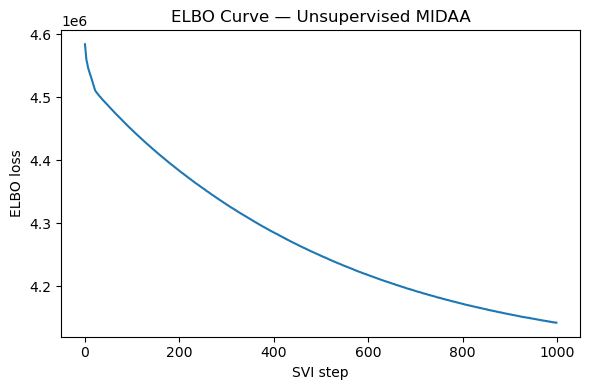

<Figure size 640x480 with 0 Axes>

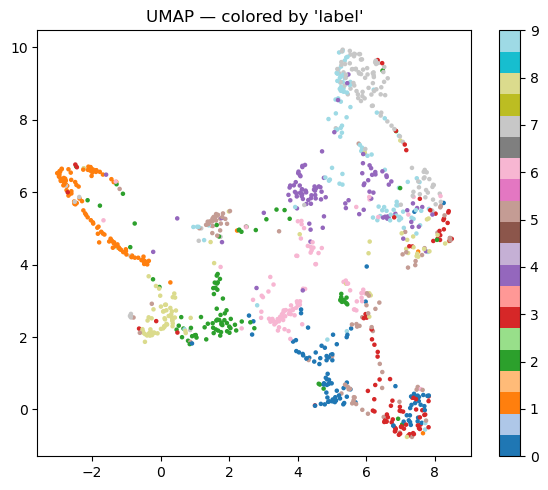

<Figure size 640x480 with 0 Axes>

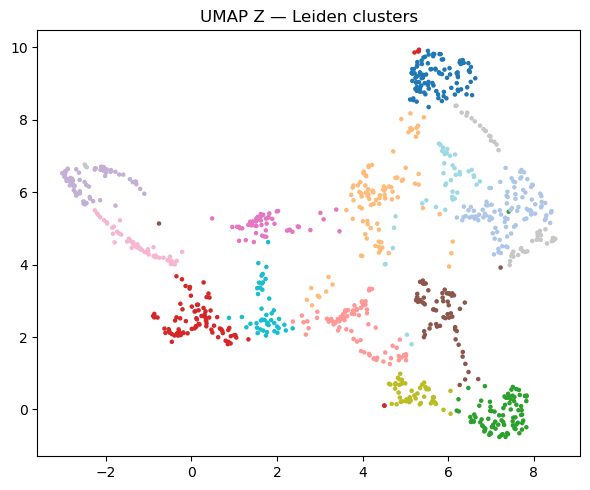

✓ Section 2 completed successfully.


<Figure size 640x480 with 0 Axes>

In [39]:
# ============================================
# SECTION 2 — MIDAA UNSUPERVISED (SCRNA-SEQ, USING 'label')
# ============================================

import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import anndata as ad
import umap
import wandb
import midaa as maa

print("Running MIDAA unsupervised...")

wandb.init(project="midaa-scrna", name="unsupervised_run", reinit=True)

# ---------------------------------------------------------
# SAFETY: ensure dense input
# ---------------------------------------------------------
if hasattr(adata.X, "toarray"):
    X_dense = adata.X.toarray().astype("float32")
else:
    X_dense = adata.X.astype("float32")

# ---------------------------------------------------------
# RUN MIDAA (unsupervised)
# ---------------------------------------------------------

res_unsup = maa.fit_MIDAA(
    input_matrix=[X_dense],
    normalization_factor=[np.ones(adata.n_obs)],
    input_types=["G"],
    loss_weights_reconstruction=[1.0],
    side_matrices=None,
    input_types_side=None,
    loss_weights_side=None,
    lr=0.001,
    steps=1000,
    narchetypes=10
)

# Extract Z and A
Z = res_unsup["inferred_quantities"]["Z"]
A = res_unsup["inferred_quantities"]["archetypes_inferred"]

print("Z shape:", Z.shape)
print("A shape:", A.shape)

# ---------------------------------------------------------
# ELBO
# ---------------------------------------------------------

plt.figure(figsize=(6,4))
maa.plot_ELBO(res_unsup)
plt.title("ELBO Curve — Unsupervised MIDAA")
plt.tight_layout()
plt.show()

wandb.log({"ELBO_unsupervised": wandb.Image(plt.gcf())})

# ---------------------------------------------------------
# UMAP — colored by label
# ---------------------------------------------------------

label_key = "label"    # <-- this is the ONLY column you have

labels = adata.obs[label_key].astype("category").cat.codes.values

reducer = umap.UMAP(n_neighbors=30, min_dist=0.1)
Z_umap = reducer.fit_transform(Z)

plt.figure(figsize=(6,5))
plt.scatter(
    Z_umap[:,0], Z_umap[:,1],
    s=5,
    c=labels,
    cmap="tab20"
)
plt.title(f"UMAP — colored by '{label_key}'")
plt.colorbar()
plt.tight_layout()
plt.show()

wandb.log({"UMAP_Z_unsupervised": wandb.Image(plt.gcf())})

# ---------------------------------------------------------
# LEIDEN CLUSTERING
# ---------------------------------------------------------

tmp = ad.AnnData(Z)
sc.pp.neighbors(tmp)
sc.tl.leiden(tmp)

adata.obs["leiden_unsup"] = tmp.obs["leiden"]

plt.figure(figsize=(6,5))
plt.scatter(
    Z_umap[:,0], Z_umap[:,1],
    s=5,
    c=adata.obs["leiden_unsup"].astype("category").cat.codes,
    cmap="tab20"
)
plt.title("UMAP Z — Leiden clusters")
plt.tight_layout()
plt.show()

wandb.log({"UMAP_Z_Leiden_unsupervised": wandb.Image(plt.gcf())})

print("✓ Section 2 completed successfully.")


Running MIDAA supervised...
Side matrix shape: (1000, 10)


ELBO: 4140162.50000  : 100%|████████████████| 1000/1000 [00:48<00:00, 20.72it/s]


✓ MIDAA supervised done.
Building simplex plot...


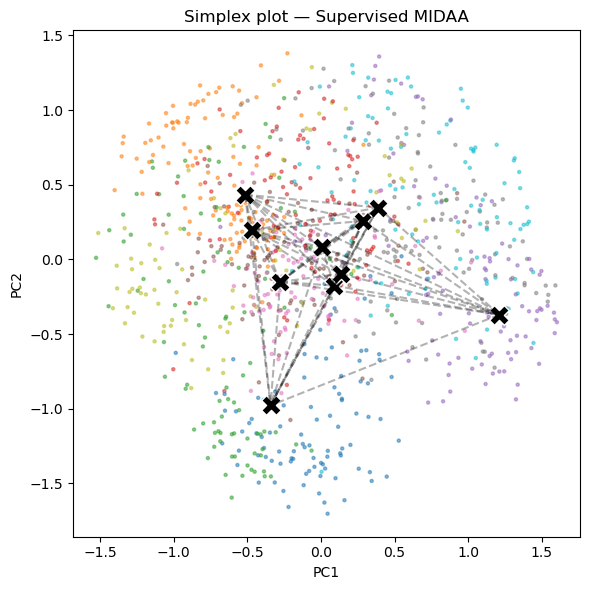

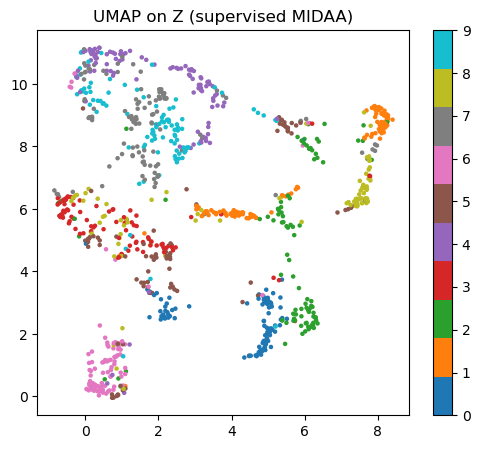

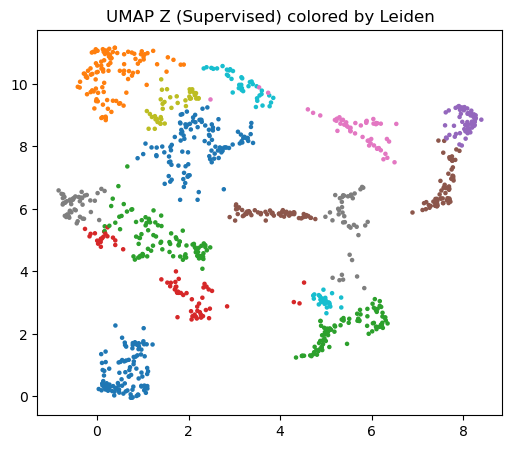

✓ MIDAA supervised section completed.


In [41]:
# ============================================
# SECTION 3 — MIDAA SUPERVISED (FIXED VERSION)
# ============================================

print("Running MIDAA supervised...")

import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import anndata as ad
import umap
import midaa as maa

# ---------------------------------------------------------
# 1. SIDE-MATRIX (ONE-HOT ENCODING)
# ---------------------------------------------------------

# adata.obs["label"] already contains 0–9 integers from preprocessing
labels = adata.obs["label"].astype(int).values

num_classes = labels.max() + 1
side_mat = np.eye(num_classes)[labels].astype(float)

print("Side matrix shape:", side_mat.shape)


# ---------------------------------------------------------
# 2. Run MIDAA (supervised)
# ---------------------------------------------------------

res_sup = maa.fit_MIDAA(
    input_matrix=[adata.X],
    normalization_factor=[np.ones(adata.n_obs)],
    input_types=["G"],

    side_matrices=[side_mat],        # <-- supervised side info
    input_types_side=["C"],          # categorical
    loss_weights_side=[1.0],
    loss_weights_reconstruction=[1.0],

    lr=0.001,
    steps=1000,
    narchetypes=10,
    fix_Z=False
)

print("✓ MIDAA supervised done.")


# ---------------------------------------------------------
# 3. FIXED SIMPLEX PLOT (no MIDAA bugs)
# ---------------------------------------------------------

print("Building simplex plot...")

from sklearn.decomposition import PCA

Z_sup = res_sup["inferred_quantities"]["Z"]
A_sup = res_sup["inferred_quantities"]["archetypes_inferred"]

# PCA projection
pca = PCA(n_components=2)
Z_sup_pca = pca.fit_transform(Z_sup)
A_sup_pca = pca.transform(A_sup)

K = A_sup.shape[0]

plt.figure(figsize=(6,6))

# Samples colored by label
plt.scatter(
    Z_sup_pca[:,0], Z_sup_pca[:,1],
    s=5,
    c=labels,
    cmap="tab10",
    alpha=0.5
)

# Archetypes
plt.scatter(
    A_sup_pca[:,0], A_sup_pca[:,1],
    s=200,
    marker="X",
    c="black",
    edgecolor="white"
)

# Simplex edges
for i in range(K):
    for j in range(i+1, K):
        plt.plot(
            [A_sup_pca[i,0], A_sup_pca[j,0]],
            [A_sup_pca[i,1], A_sup_pca[j,1]],
            "k--",
            alpha=0.3
        )

plt.title("Simplex plot — Supervised MIDAA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 4. UMAP PÅ Z (supervised)
# ---------------------------------------------------------

reducer = umap.UMAP(n_neighbors=30, min_dist=0.1)
Z_sup_umap = reducer.fit_transform(Z_sup)

plt.figure(figsize=(6,5))
plt.scatter(
    Z_sup_umap[:,0], Z_sup_umap[:,1],
    s=5,
    c=labels,
    cmap="tab10"
)
plt.title("UMAP on Z (supervised MIDAA)")
plt.colorbar()
plt.show()


# ---------------------------------------------------------
# 5. LEIDEN CLUSTERING (stable replacement for Louvain)
# ---------------------------------------------------------

tmp2 = ad.AnnData(Z_sup)
sc.pp.neighbors(tmp2)
sc.tl.leiden(tmp2)

adata.obs["leiden_sup"] = tmp2.obs["leiden"].values

plt.figure(figsize=(6,5))
plt.scatter(
    Z_sup_umap[:,0], Z_sup_umap[:,1],
    s=5,
    c=adata.obs["leiden_sup"].astype("category").cat.codes,
    cmap="tab10"
)
plt.title("UMAP Z (Supervised) colored by Leiden")
plt.show()

print("✓ MIDAA supervised section completed.")



SECTION 4: MLP Decoder — starting...
Latent dim: 9
Loaded Z, A, and X successfully.
✓ MLP Decoder initialized.
Training MLP decoder...
Epoch 1/40 — loss: 0.8756
Epoch 2/40 — loss: 0.6626
Epoch 3/40 — loss: 0.3909
Epoch 4/40 — loss: 0.2769
Epoch 5/40 — loss: 0.2592
Epoch 6/40 — loss: 0.2518
Epoch 7/40 — loss: 0.2440
Epoch 8/40 — loss: 0.2363
Epoch 9/40 — loss: 0.2291
Epoch 10/40 — loss: 0.2226
Epoch 11/40 — loss: 0.2175
Epoch 12/40 — loss: 0.2129
Epoch 13/40 — loss: 0.2093
Epoch 14/40 — loss: 0.2061
Epoch 15/40 — loss: 0.2033
Epoch 16/40 — loss: 0.2008
Epoch 17/40 — loss: 0.1984
Epoch 18/40 — loss: 0.1966
Epoch 19/40 — loss: 0.1948
Epoch 20/40 — loss: 0.1933
Epoch 21/40 — loss: 0.1916
Epoch 22/40 — loss: 0.1905
Epoch 23/40 — loss: 0.1890
Epoch 24/40 — loss: 0.1879
Epoch 25/40 — loss: 0.1869
Epoch 26/40 — loss: 0.1858
Epoch 27/40 — loss: 0.1848
Epoch 28/40 — loss: 0.1836
Epoch 29/40 — loss: 0.1825
Epoch 30/40 — loss: 0.1817
Epoch 31/40 — loss: 0.1808
Epoch 32/40 — loss: 0.1799
Epoch 33/4

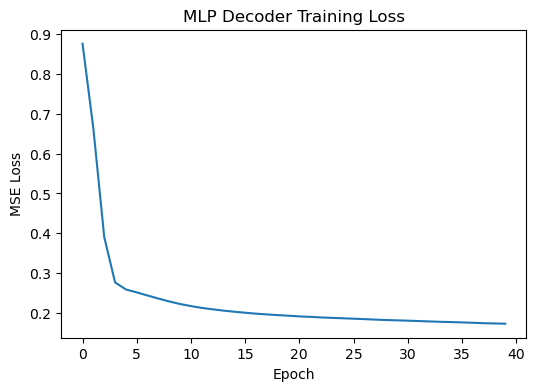

✓ MLP decoder training complete.


<Figure size 640x480 with 0 Axes>

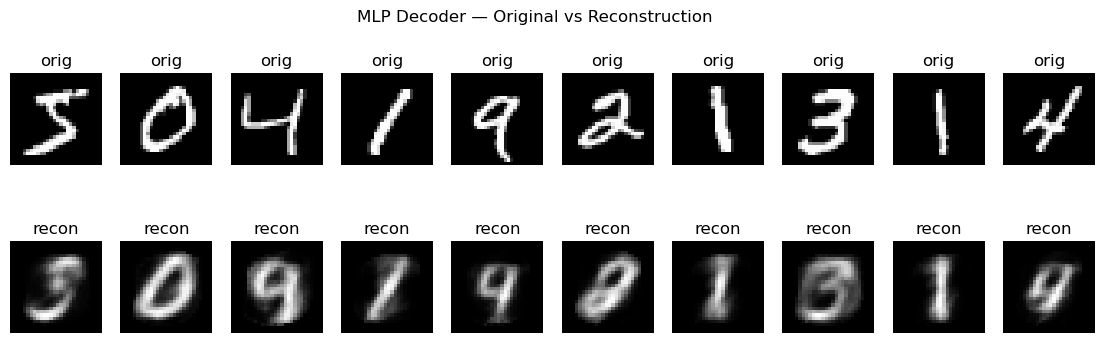

<Figure size 640x480 with 0 Axes>

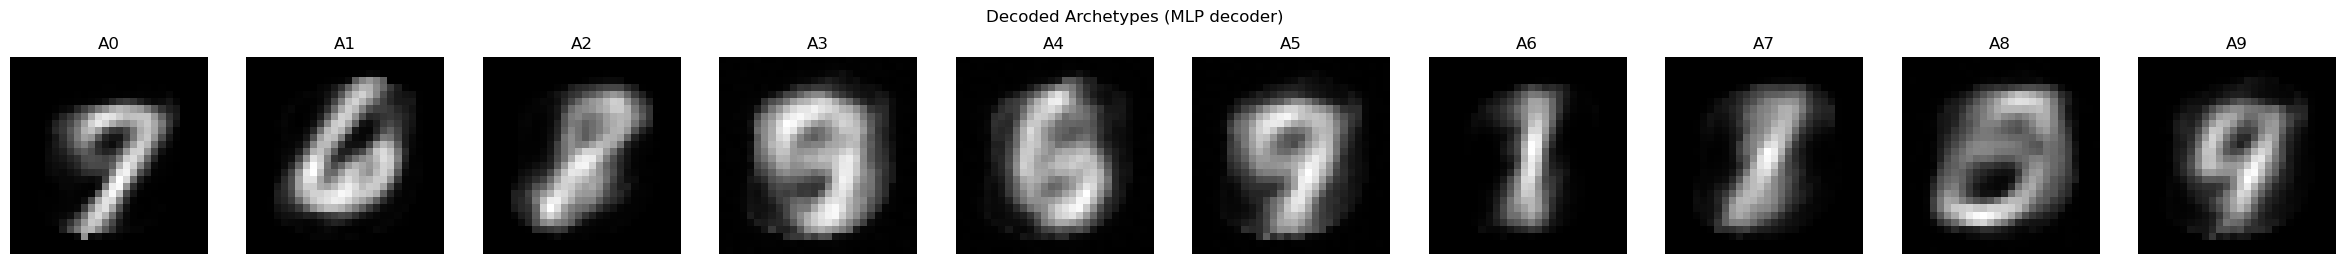

✓ SECTION 4 completed successfully.


<Figure size 640x480 with 0 Axes>

In [42]:
# ============================================
# SECTION 4 — MLP DECODER (FIXED + CLEAN)
# ============================================

print("SECTION 4: MLP Decoder — starting...")

# ---------------------------------------------------------
# 1) Load Z and X from UNSUPERVISED MIDAA
# ---------------------------------------------------------

# IMPORTANT: use the correct variable name from Section 2
Z = res_unsup["inferred_quantities"]["Z"]          # (N, latent_dim)
A = res_unsup["inferred_quantities"]["archetypes_inferred"]
X = adata.X                                        # (N, 784)
latent_dim = Z.shape[1]

print("Latent dim:", latent_dim)
print("Loaded Z, A, and X successfully.")

# ---------------------------------------------------------
# 2) Define the MLP Decoder
# ---------------------------------------------------------

class MLPDecoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.ReLU(),
            nn.Linear(256, 512), nn.ReLU(),
            nn.Linear(512, 784), nn.Sigmoid()
        )
        
    def forward(self, z):
        return self.net(z)

decoder = MLPDecoder(latent_dim)
optimizer = optim.Adam(decoder.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

print("✓ MLP Decoder initialized.")


# ---------------------------------------------------------
# 3) Train the decoder
# ---------------------------------------------------------

Z_t = torch.tensor(Z).float()
X_t = torch.tensor(X).float()

loss_history = []
epochs = 40
batch_size = 256

loader = DataLoader(TensorDataset(Z_t, X_t), batch_size=batch_size, shuffle=True)

print("Training MLP decoder...")

for ep in range(epochs):
    total_loss = 0
    for z_batch, x_batch in loader:
        optimizer.zero_grad()
        x_pred = decoder(z_batch)
        loss = loss_fn(x_pred, x_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    loss_history.append(total_loss)
    print(f"Epoch {ep+1}/{epochs} — loss: {total_loss:.4f}")

# plot + log
plt.figure(figsize=(6,4))
plt.plot(loss_history)
plt.title("MLP Decoder Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

wandb.log({"decoder_training_loss": wandb.Image(plt.gcf())})
print("✓ MLP decoder training complete.")


# ---------------------------------------------------------
# 4) Reconstructions
# ---------------------------------------------------------

decoder.eval()
X_rec = decoder(Z_t).detach().numpy()

plt.figure(figsize=(14,4))
n = 10
for i in range(n):
    plt.subplot(2, n, i+1)
    plt.imshow(X[i].reshape(28,28), cmap="gray")
    plt.title("orig")
    plt.axis("off")

    plt.subplot(2, n, n+i+1)
    plt.imshow(X_rec[i].reshape(28,28), cmap="gray")
    plt.title("recon")
    plt.axis("off")

plt.suptitle("MLP Decoder — Original vs Reconstruction")
plt.show()

wandb.log({"reconstructions_mlp": wandb.Image(plt.gcf())})


# ---------------------------------------------------------
# 5) Decode archetypes (FULLY FIXED)
# ---------------------------------------------------------

A_t = torch.tensor(A).float()
A_dec = decoder(A_t).detach().numpy()

K = A_dec.shape[0]

plt.figure(figsize=(3*K, 3))
for k in range(K):
    plt.subplot(1, K, k+1)
    plt.imshow(A_dec[k].reshape(28,28), cmap="gray")
    plt.title(f"A{k}")
    plt.axis("off")

plt.suptitle("Decoded Archetypes (MLP decoder)")
plt.show()

wandb.log({"decoded_archetypes": wandb.Image(plt.gcf())})

print("✓ SECTION 4 completed successfully.")



SECTION 5: ConvDecoder — starting...
✓ ConvDecoder initialized.
Training ConvDecoder...
[Conv] Epoch 1/40 — loss: 0.8990
[Conv] Epoch 2/40 — loss: 0.8132
[Conv] Epoch 3/40 — loss: 0.6463
[Conv] Epoch 4/40 — loss: 0.4832
[Conv] Epoch 5/40 — loss: 0.4389
[Conv] Epoch 6/40 — loss: 0.4386
[Conv] Epoch 7/40 — loss: 0.4386
[Conv] Epoch 8/40 — loss: 0.4373
[Conv] Epoch 9/40 — loss: 0.4360
[Conv] Epoch 10/40 — loss: 0.4340
[Conv] Epoch 11/40 — loss: 0.4309
[Conv] Epoch 12/40 — loss: 0.4257
[Conv] Epoch 13/40 — loss: 0.4163
[Conv] Epoch 14/40 — loss: 0.3998
[Conv] Epoch 15/40 — loss: 0.3742
[Conv] Epoch 16/40 — loss: 0.3504
[Conv] Epoch 17/40 — loss: 0.3381
[Conv] Epoch 18/40 — loss: 0.3210
[Conv] Epoch 19/40 — loss: 0.3026
[Conv] Epoch 20/40 — loss: 0.2872
[Conv] Epoch 21/40 — loss: 0.2713
[Conv] Epoch 22/40 — loss: 0.2592
[Conv] Epoch 23/40 — loss: 0.2490
[Conv] Epoch 24/40 — loss: 0.2407
[Conv] Epoch 25/40 — loss: 0.2343
[Conv] Epoch 26/40 — loss: 0.2291
[Conv] Epoch 27/40 — loss: 0.2250
[Co

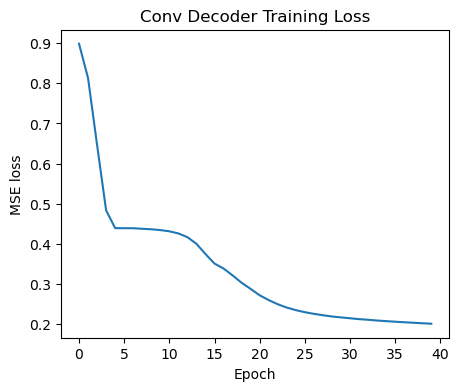

✓ ConvDecoder training finished.


<Figure size 640x480 with 0 Axes>

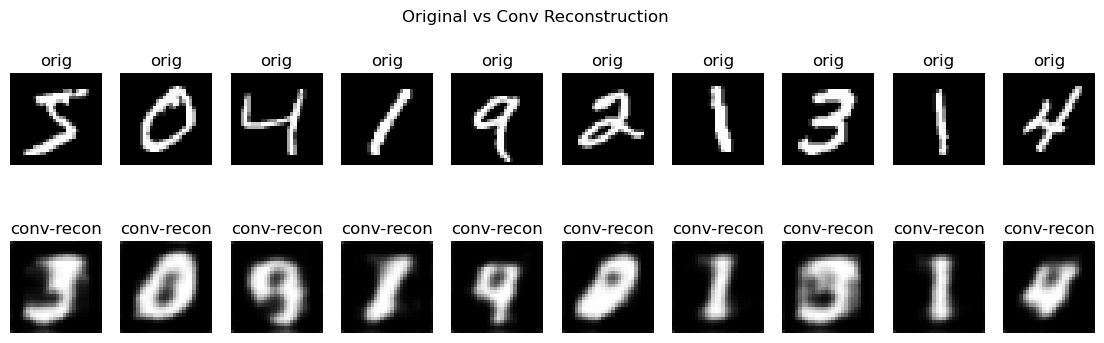

<Figure size 640x480 with 0 Axes>

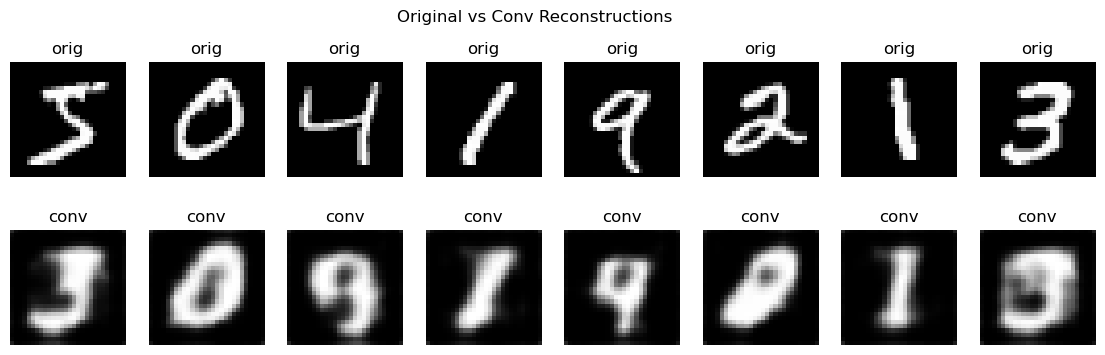

<Figure size 640x480 with 0 Axes>

In [43]:
# ============================================
# SECTION 5 — CONV DECODER (CNN) + TRAINING + RECON + COMPARISON
# ============================================

print("SECTION 5: ConvDecoder — starting...")

# ============================================
# 1) FORBEREDELSE
# ============================================

latent_dim = Z.shape[1]

# Reshape X til 1×28×28 (CNN input)
X_img = X.reshape(-1, 1, 28, 28)
X_img_t = torch.tensor(X_img).float()

# ============================================
# 2) DEFINER CONV DECODER
# ============================================

class ConvDecoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 7*7*64),
            nn.ReLU()
        )
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # 7→14
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),  # 14→28
            nn.ReLU(),
            nn.Conv2d(16, 1, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 64, 7, 7)
        x = self.deconv(x)
        return x

conv_decoder = ConvDecoder(latent_dim)
optimizer_c = optim.Adam(conv_decoder.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

print("✓ ConvDecoder initialized.")


# ============================================
# 3) TRÆN CNN DECODER
# ============================================

Z_t = torch.tensor(Z).float()

epochs = 40
batch_size = 256

dataset = TensorDataset(Z_t, X_img_t)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

loss_history_conv = []

print("Training ConvDecoder...")

for ep in range(epochs):
    total = 0
    for z_batch, x_batch in loader:
        optimizer_c.zero_grad()
        pred = conv_decoder(z_batch)
        loss = loss_fn(pred, x_batch)
        loss.backward()
        optimizer_c.step()
        total += loss.item()

    loss_history_conv.append(total)
    print(f"[Conv] Epoch {ep+1}/{epochs} — loss: {total:.4f}")

# Log training curve
plt.figure(figsize=(5,4))
plt.plot(loss_history_conv)
plt.title("Conv Decoder Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.show()

wandb.log({"conv_decoder_training_loss": wandb.Image(plt.gcf())})

print("✓ ConvDecoder training finished.")


# ============================================
# 4) CONV RECONSTRUCTIONS
# ============================================

conv_decoder.eval()
X_conv_hat = conv_decoder(Z_t).detach().numpy()

plt.figure(figsize=(14,4))
n = 10
for i in range(n):
    # original
    plt.subplot(2, n, i+1)
    plt.imshow(X_img[i,0], cmap="gray")
    plt.title("orig")
    plt.axis("off")

    # reconstructed
    plt.subplot(2, n, n+i+1)
    plt.imshow(X_conv_hat[i,0], cmap="gray")
    plt.title("conv-recon")
    plt.axis("off")

plt.suptitle("Original vs Conv Reconstruction")
plt.show()

wandb.log({"conv_reconstruction_grid": wandb.Image(plt.gcf())})


# ============================================
# 5) SAMMENLIGNING: ORIGINAL vs CONV
# ============================================

plt.figure(figsize=(14,4))
n = 8

for i in range(n):

    # Original
    plt.subplot(2, n, i+1)
    plt.imshow(X_img[i,0], cmap="gray")
    plt.title("orig")
    plt.axis("off")

    # Conv recon
    plt.subplot(2, n, n+i+1)
    plt.imshow(X_conv_hat[i,0], cmap="gray")
    plt.title("conv")
    plt.axis("off")

plt.suptitle("Original vs Conv Reconstructions")
plt.show()

wandb.log({"conv_recon_only": wandb.Image(plt.gcf())})


SECTION 6: Latent space analysis...
✓ Z shape: (1000, 9)
✓ A shape: (10, 9)
✓ S: NOT present in this MIDAA version


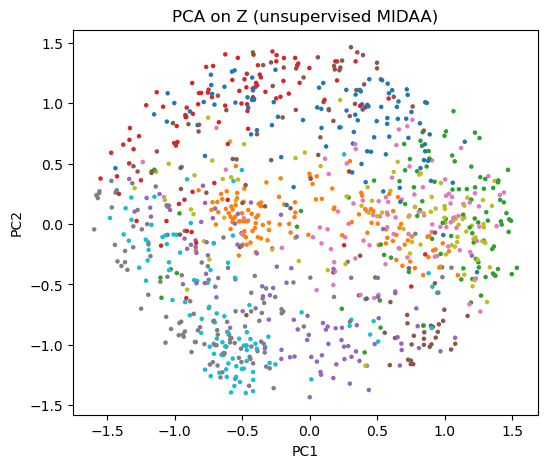

<Figure size 640x480 with 0 Axes>

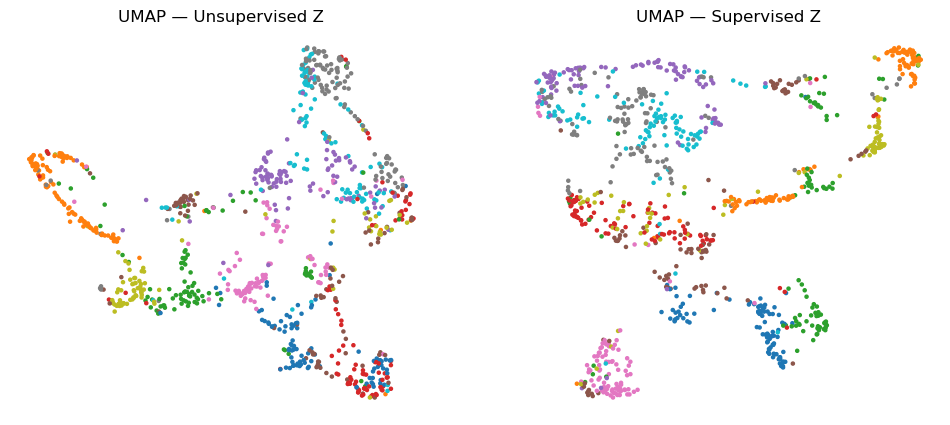

<Figure size 640x480 with 0 Axes>

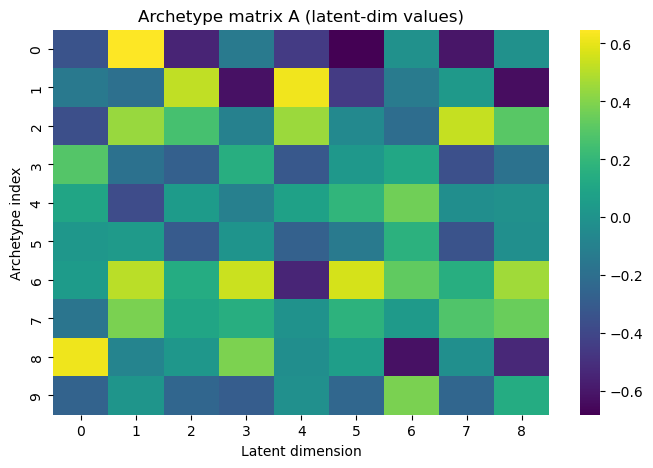

skipping S visualization.


<Figure size 640x480 with 0 Axes>

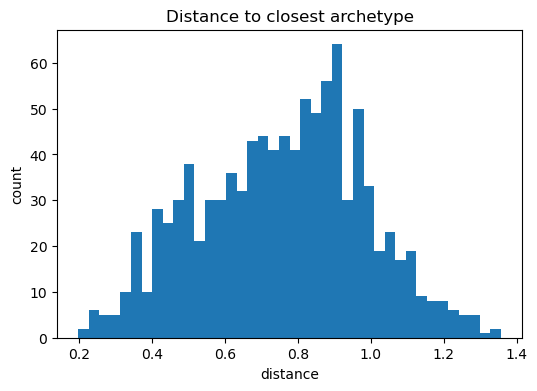

<Figure size 640x480 with 0 Axes>

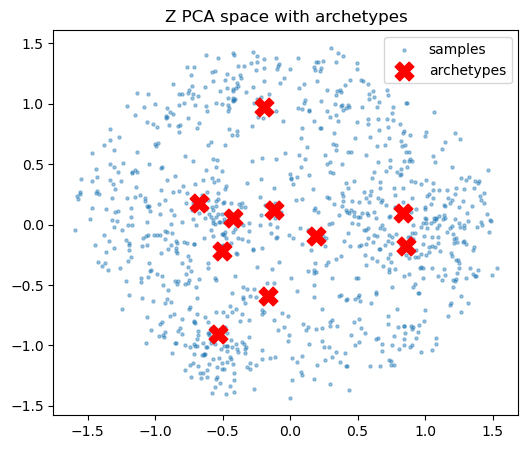

<Figure size 640x480 with 0 Axes>

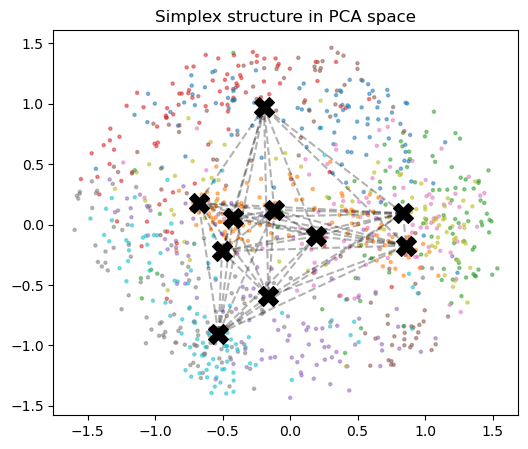

✓ SECTION 6 complete.


<Figure size 640x480 with 0 Axes>

In [44]:
# ============================================
# SECTION 6 — LATENT SPACE ANALYSIS (PCA, UMAP, A, S, DISTANCES)
# ============================================

print("SECTION 6: Latent space analysis...")

# --------------------------------------------
# HENT RELEVANTE VARIABLER
# --------------------------------------------
Z = res_unsup["inferred_quantities"]["Z"]    
A = res_unsup["inferred_quantities"]["archetypes_inferred"]
S = res_unsup["inferred_quantities"]["S_inferred"] if "S_inferred" in res_unsup["inferred_quantities"] else None

labels = adata.obs["label"].astype(int).values
K = A.shape[0]

print("✓ Z shape:", Z.shape)
print("✓ A shape:", A.shape)
print("✓ S:", "found" if S is not None else "NOT present in this MIDAA version")


# ============================================
# 1) PCA PÅ Z
# ============================================

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
Z_pca = pca.fit_transform(Z)

plt.figure(figsize=(6,5))
plt.scatter(Z_pca[:,0], Z_pca[:,1], s=5, c=labels, cmap="tab10")
plt.title("PCA on Z (unsupervised MIDAA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

wandb.log({"PCA_Z_unsupervised": wandb.Image(plt.gcf())})


# ============================================
# 2) UMAP (supervised vs unsupervised sammenligning)
# ============================================

reducer = umap.UMAP(n_neighbors=30, min_dist=0.1)
Z_sup = res_sup["inferred_quantities"]["Z"]
Z_sup_umap = reducer.fit_transform(Z_sup)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(Z_umap[:,0], Z_umap[:,1], s=5, c=labels, cmap="tab10")
plt.title("UMAP — Unsupervised Z")
plt.axis("off")

plt.subplot(1,2,2)
plt.scatter(Z_sup_umap[:,0], Z_sup_umap[:,1], s=5, c=labels, cmap="tab10")
plt.title("UMAP — Supervised Z")
plt.axis("off")

plt.show()

wandb.log({"UMAP_unsup_vs_sup": wandb.Image(plt.gcf())})


# ============================================
# 3) ARCHETYPE HEATMAP (A-MATRIX)
# ============================================

plt.figure(figsize=(8,5))
sns.heatmap(A, cmap="viridis", annot=False)
plt.title("Archetype matrix A (latent-dim values)")
plt.xlabel("Latent dimension")
plt.ylabel("Archetype index")
plt.show()

wandb.log({"A_heatmap": wandb.Image(plt.gcf())})


# ============================================
# 4) S-VISUALISERING (archetype weights pr. sample)
# ============================================

if S is not None:
    plt.figure(figsize=(8,5))
    sns.heatmap(S[:200], cmap="magma", cbar=True)
    plt.title("S_inferred (first 200 samples)")
    plt.xlabel("Archetype")
    plt.ylabel("Sample")
    plt.show()

    wandb.log({"S_heatmap": wandb.Image(plt.gcf())})
else:
    print("skipping S visualization.")


# ============================================
# 5) DISTANCE TIL NÆRMESTE ARCHETYPE
# ============================================

dists = np.sqrt(((Z[:,None,:] - A[None,:,:])**2).sum(axis=2))   # (N × K)
min_dist = dists.min(axis=1)

plt.figure(figsize=(6,4))
plt.hist(min_dist, bins=40)
plt.title("Distance to closest archetype")
plt.xlabel("distance")
plt.ylabel("count")
plt.show()

wandb.log({"distance_to_archetype": wandb.Image(plt.gcf())})


# ============================================
# 6) Z-SPACE MED ARCHETYPES MARKERET
# ============================================

plt.figure(figsize=(6,5))
plt.scatter(Z_pca[:,0], Z_pca[:,1], s=5, alpha=0.4)
plt.scatter(pca.transform(A)[:,0], pca.transform(A)[:,1], s=180, marker="X", c="red")
plt.title("Z PCA space with archetypes")
plt.legend(["samples", "archetypes"])
plt.show()

wandb.log({"Z_PCA_with_archetypes": wandb.Image(plt.gcf())})


# ============================================
# 7) SIMPLEX PLOT I PCA-RUMMET
# ============================================

plt.figure(figsize=(6,5))
plt.scatter(Z_pca[:,0], Z_pca[:,1], s=5, c=labels, cmap="tab10", alpha=0.5)

# tegn linjer mellem archetypes
A_pca = pca.transform(A)
for i in range(K):
    for j in range(i+1, K):
        plt.plot([A_pca[i,0], A_pca[j,0]],
                 [A_pca[i,1], A_pca[j,1]],
                 "k--", alpha=0.3)

plt.scatter(A_pca[:,0], A_pca[:,1], s=200, marker="X", c="black")
plt.title("Simplex structure in PCA space")
plt.show()

wandb.log({"simplex_in_PCA": wandb.Image(plt.gcf())})

print("✓ SECTION 6 complete.")


SECTION 7: interpolation, sampling, archetype paths...


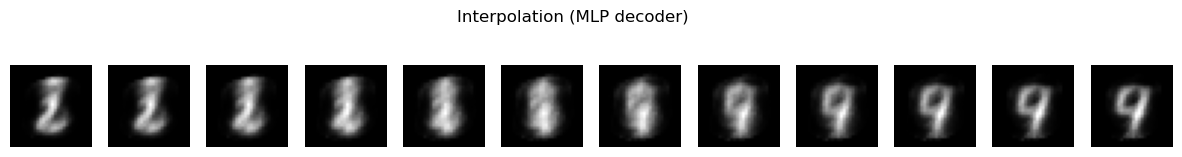

<Figure size 640x480 with 0 Axes>

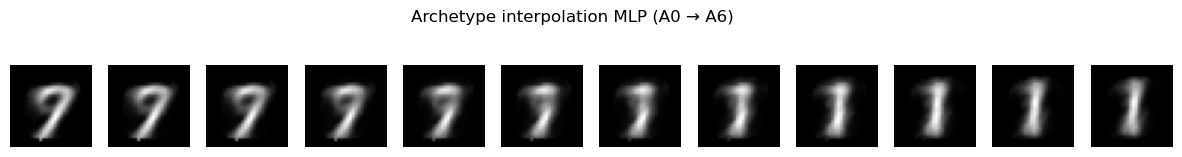

<Figure size 640x480 with 0 Axes>

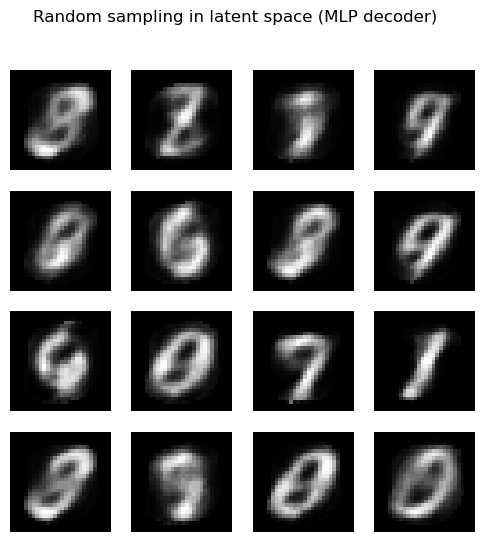

<Figure size 640x480 with 0 Axes>

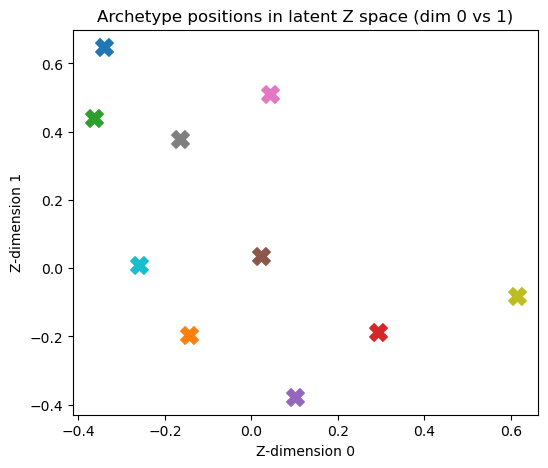

✓ SECTION 7 completed.


<Figure size 640x480 with 0 Axes>

In [45]:
# ============================================
# SECTION 7 — INTERPOLATION + SAMPLING + ARCHETYPE PATHS
# ============================================

print("SECTION 7: interpolation, sampling, archetype paths...")

# -------------------------------
# Helper to decode using either MLP or Conv decoder
# -------------------------------
def decode(decoder, z, conv=False):
    z_t = torch.tensor(z).float()
    out = decoder(z_t).detach().numpy()
    if conv:
        out = out[:,0,:,:]   # (N,1,28,28) → (N,28,28)
    else:
        out = out.reshape(-1, 28, 28)
    return out


# ============================================
# 1) INTERPOLATION MELLEM TO RANDOM SAMPLES
# ============================================

idx1, idx2 = np.random.choice(len(Z), 2, replace=False)
z1, z2 = Z[idx1], Z[idx2]

alphas = np.linspace(0, 1, 12)
Z_interp = np.array([(1-a)*z1 + a*z2 for a in alphas])

# MLP decode
interp_imgs_mlp = decode(decoder, Z_interp, conv=False)

plt.figure(figsize=(15,2))
for i in range(len(alphas)):
    plt.subplot(1, len(alphas), i+1)
    plt.imshow(interp_imgs_mlp[i], cmap="gray")
    plt.axis("off")
plt.suptitle("Interpolation (MLP decoder)")
plt.show()

wandb.log({"interpolation_mlp": wandb.Image(plt.gcf())})


# ============================================
# 2) INTERPOLATION MELLEM TO ARCHETYPES
# ============================================

A = res_unsup["inferred_quantities"]["archetypes_inferred"]

k1, k2 = np.random.choice(A.shape[0], 2, replace=False)
A1, A2 = A[k1], A[k2]

Z_interp_A = np.array([(1-a)*A1 + a*A2 for a in alphas])

interp_A_imgs = decode(decoder, Z_interp_A, conv=False)

plt.figure(figsize=(15,2))
for i in range(len(alphas)):
    plt.subplot(1, len(alphas), i+1)
    plt.imshow(interp_A_imgs[i], cmap="gray")
    plt.axis("off")
plt.suptitle(f"Archetype interpolation MLP (A{k1} → A{k2})")
plt.show()

wandb.log({"interpolation_archetypes_mlp": wandb.Image(plt.gcf())})


# ============================================
# 3) RANDOM SAMPLING I Z-RUMMET
# ============================================

# Gaussian sampling around mean/var of Z
Z_mean = Z.mean(axis=0)
Z_std = Z.std(axis=0)

samples = np.random.normal(Z_mean, Z_std, size=(16, Z.shape[1]))

sample_imgs = decode(decoder, samples)

plt.figure(figsize=(6,6))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(sample_imgs[i], cmap="gray")
    plt.axis("off")
plt.suptitle("Random sampling in latent space (MLP decoder)")
plt.show()

wandb.log({"sampling_mlp": wandb.Image(plt.gcf())})


# ============================================
# 4) ARCHETYPE PATH VISUALIZATION
# ============================================

plt.figure(figsize=(6,5))
for k in range(A.shape[0]):
    plt.scatter(A[k,0], A[k,1], s=160, marker="X")
plt.title("Archetype positions in latent Z space (dim 0 vs 1)")
plt.xlabel("Z-dimension 0")
plt.ylabel("Z-dimension 1")
plt.show()

wandb.log({"archetype_locations_Z": wandb.Image(plt.gcf())})


print("✓ SECTION 7 completed.")
